<a href="https://colab.research.google.com/github/sadhanakumble/DemoFirst/blob/main/notebooka058aa8683.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
yeeandres_casiagdb_path = kagglehub.dataset_download('yeeandres/casiagdb')

print('Data source import complete.')


100%|██████████| 944M/944M [00:11<00:00, 83.3MB/s]

Extracting files...


Data source import complete.


In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if len(image_files) > 0:
        print("Possible GEI folder:", root)
        print("Sample files:", image_files[:5])
        break

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import cv2
import numpy as np
from tqdm import tqdm

DATASET_ROOT = "/root/.cache/kagglehub/datasets/yeeandres/casiagdb/versions/1/GaitDatasetB-silh"

SAVE_ROOT = "/content/drive/MyDrive/CASIA-B/GEI_Multiview_NM"
os.makedirs(SAVE_ROOT, exist_ok=True)

USE_CONDITIONS = ["nm"]
USE_VIEWS = ["000","018","036","054","072","090","108","126","144","162","180"]

subjects = sorted([
    s for s in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, s))
])

def generate_gei(sequence_folder, image_size=(128,128)):
    images = []

    for file in sorted(os.listdir(sequence_folder)):
        if not file.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        img_path = os.path.join(sequence_folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        img = img / 255.0
        images.append(img)

    if len(images) == 0:
        return None

    return np.mean(images, axis=0)

In [20]:
for subject in tqdm(subjects, desc="Saving GEIs"):

    subject_path = os.path.join(DATASET_ROOT, subject, subject)

    if not os.path.isdir(subject_path):
        subject_path = os.path.join(DATASET_ROOT, subject)

    subject_save_dir = os.path.join(SAVE_ROOT, subject)
    os.makedirs(subject_save_dir, exist_ok=True)

    for condition in os.listdir(subject_path):
        condition_path = os.path.join(subject_path, condition)

        if not os.path.isdir(condition_path):
            continue

        if not any(condition.startswith(c) for c in USE_CONDITIONS):
            continue

        for view in os.listdir(condition_path):
            view_path = os.path.join(condition_path, view)

            if not os.path.isdir(view_path):
                continue

            if view not in USE_VIEWS:
                continue

            save_name = f"{subject}_{condition}_{view}.npy"
            save_path = os.path.join(subject_save_dir, save_name)

            # Skip already generated GEI
            if os.path.exists(save_path):
                continue

            gei = generate_gei(view_path)

            if gei is not None:
                np.save(save_path, gei)

print("GEI saving completed.")

Saving GEIs: 100%|██████████| 124/124 [07:33<00:00,  3.66s/it]

GEI saving completed.


In [21]:
if os.path.exists(save_path):
  continue

SyntaxError: 'continue' not properly in loop (1840590975.py, line 2)

In [ ]:
X = []
y = []

subjects = sorted(os.listdir(SAVE_ROOT))
subject_map = {s: i for i, s in enumerate(subjects)}

for subject in subjects:
    subject_dir = os.path.join(SAVE_ROOT, subject)

    for file in os.listdir(subject_dir):
        if file.endswith(".npy"):
            X.append(np.load(os.path.join(subject_dir, file)))
            y.append(subject_map[subject])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
print(len(np.unique(y)))

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (6524, 128, 128)
Test : (1631, 128, 128)


In [24]:
from torch.utils.data import Dataset

class GaitDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        image = self.X[idx]

        image = np.stack([image]*3, axis=0)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        label = torch.tensor(
            self.y[idx],
            dtype=torch.long
        )

        return image, label

In [25]:
from torch.utils.data import DataLoader

train_dataset = GaitDataset(X_train, y_train)
test_dataset = GaitDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [26]:
import timm
import torch.nn as nn

class EfficientNetOnlyModel(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )

        self.classifier = nn.Linear(
            self.backbone.num_features,
            num_classes
        )

    def forward(self, x):

        features = self.backbone(x)

        return self.classifier(features)

In [27]:
import torch
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

num_classes = len(np.unique(y))

eff_model = EfficientNetOnlyModel(
    num_classes
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    eff_model.parameters(),
    lr=1e-4
)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [5]:
np.save("X_multiview_nm.npy", X)
np.save("y_multiview_nm.npy", y)

NameError: name 'X' is not defined

In [30]:
EPOCHS = 20

for epoch in range(EPOCHS):

    eff_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = eff_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_acc = correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Train Accuracy: {train_acc:.4f}"
    )

Epoch [1/20] Loss: 292.2116 Train Accuracy: 0.7154
Epoch [2/20] Loss: 165.8660 Train Accuracy: 0.8263
Epoch [3/20] Loss: 96.4736 Train Accuracy: 0.8955
Epoch [4/20] Loss: 52.5366 Train Accuracy: 0.9473
Epoch [5/20] Loss: 31.0787 Train Accuracy: 0.9730
Epoch [6/20] Loss: 18.3639 Train Accuracy: 0.9848
Epoch [7/20] Loss: 13.2323 Train Accuracy: 0.9903
Epoch [8/20] Loss: 9.5717 Train Accuracy: 0.9923
Epoch [9/20] Loss: 5.4591 Train Accuracy: 0.9972
Epoch [10/20] Loss: 7.0527 Train Accuracy: 0.9942
Epoch [11/20] Loss: 5.4758 Train Accuracy: 0.9960
Epoch [12/20] Loss: 6.7443 Train Accuracy: 0.9942
Epoch [13/20] Loss: 5.8051 Train Accuracy: 0.9952
Epoch [14/20] Loss: 9.1087 Train Accuracy: 0.9893
Epoch [15/20] Loss: 5.7222 Train Accuracy: 0.9940
Epoch [16/20] Loss: 4.9545 Train Accuracy: 0.9943
Epoch [17/20] Loss: 8.3135 Train Accuracy: 0.9905
Epoch [18/20] Loss: 6.4273 Train Accuracy: 0.9929
Epoch [19/20] Loss: 4.4727 Train Accuracy: 0.9960
Epoch [20/20] Loss: 2.6707 Train Accuracy: 0.9971


In [31]:
# ==========================================================
# Model Evaluation Code
# ==========================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import torch

eff_model.eval()

predictions = []
ground_truth = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = eff_model(images)

        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        ground_truth.extend(labels.cpu().numpy())

accuracy = accuracy_score(ground_truth, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(
    classification_report(
        ground_truth,
        predictions,
        zero_division=0
    )
)

print("\nConfusion Matrix:\n")
print(confusion_matrix(ground_truth, predictions))

Accuracy: 0.9405272838749233

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       1.00      1.00      1.00        14
           2       1.00      0.93      0.96        14
           3       1.00      1.00      1.00        13
           4       0.85      0.92      0.88        12
           5       1.00      1.00      1.00        13
           6       1.00      1.00      1.00        13
           7       1.00      1.00      1.00        13
           8       1.00      0.85      0.92        13
           9       1.00      1.00      1.00        13
          10       0.85      0.85      0.85        13
          11       0.93      1.00      0.96        13
          12       1.00      0.92      0.96        13
          13       1.00      0.85      0.92        13
          14       1.00      0.92      0.96        13
          15       1.00      0.79      0.88        14
          16       0.80    

In [32]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 94.05%


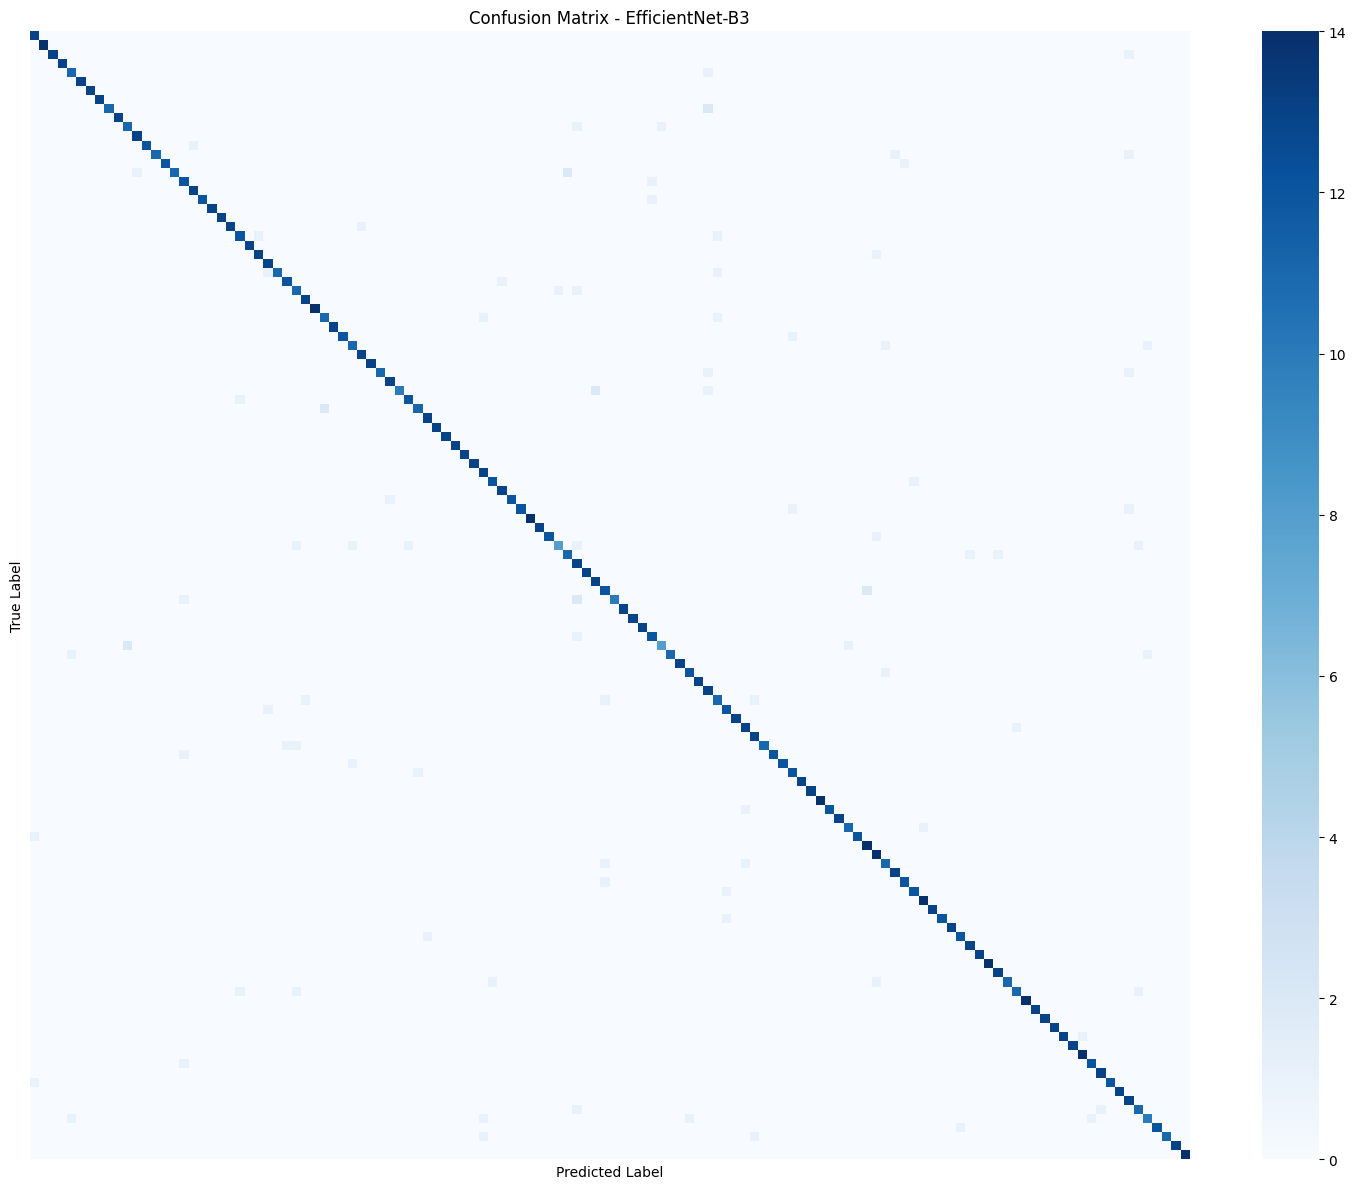

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ground_truth, predictions)

plt.figure(figsize=(15,12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("Confusion Matrix - EfficientNet-B3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("confusion_matrix_efficientnet.png", dpi=300)
plt.show()

In [34]:
train_losses = []

In [35]:
train_losses.append(running_loss)

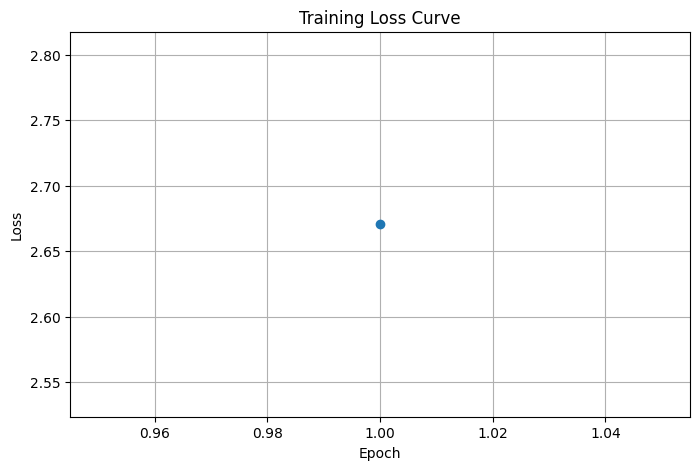

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(train_losses)+1),
    train_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid(True)

plt.savefig("loss_curve.png", dpi=300)
plt.show()

In [37]:
train_accs = []

In [38]:
train_accs.append(train_acc)

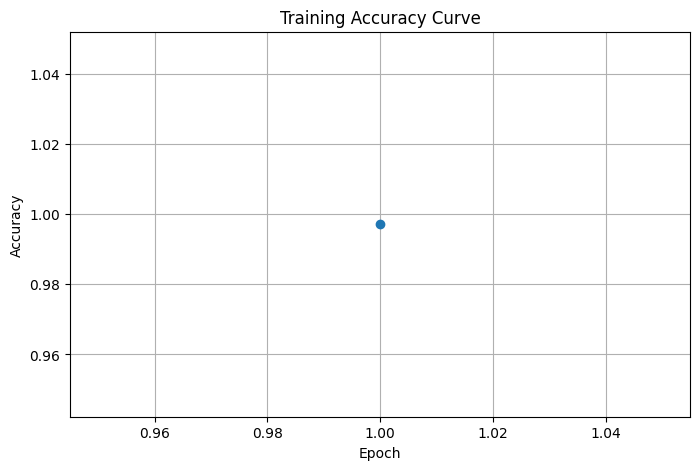

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(train_accs)+1),
    train_accs,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")

plt.grid(True)

plt.savefig("accuracy_curve.png", dpi=300)
plt.show()

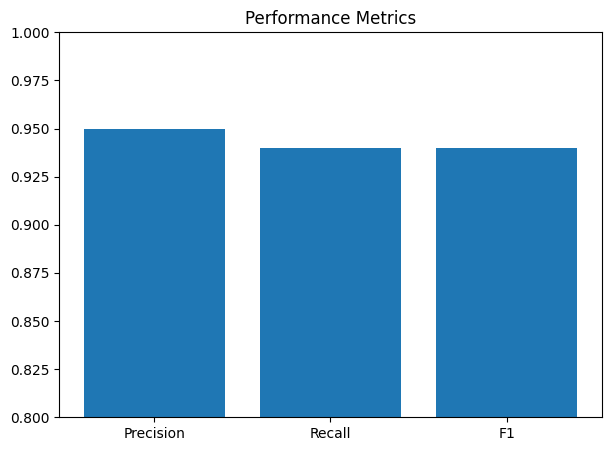

In [40]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Precision","Recall","F1"]

values = [0.95,0.94,0.94]

plt.figure(figsize=(7,5))

plt.bar(metrics, values)

plt.ylim([0.8,1.0])

plt.title("Performance Metrics")

plt.savefig("metrics_comparison.png", dpi=300)

plt.show()

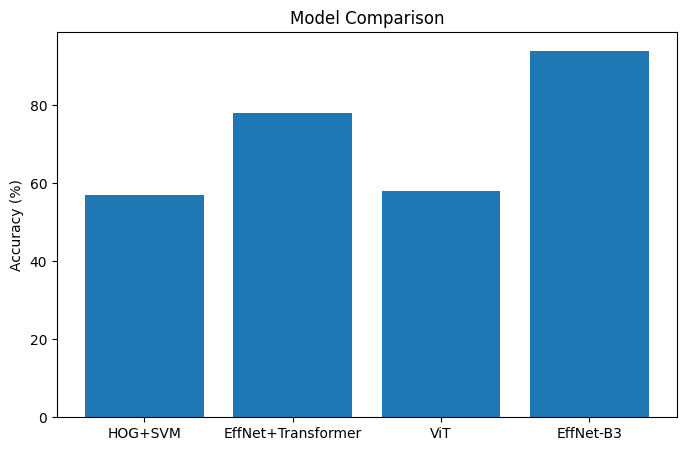

In [41]:
models = [
    "HOG+SVM",
    "EffNet+Transformer",
    "ViT",
    "EffNet-B3"
]

accuracy = [
    57,
    78,
    58,
    94
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.savefig("model_comparison.png", dpi=300)

plt.show()

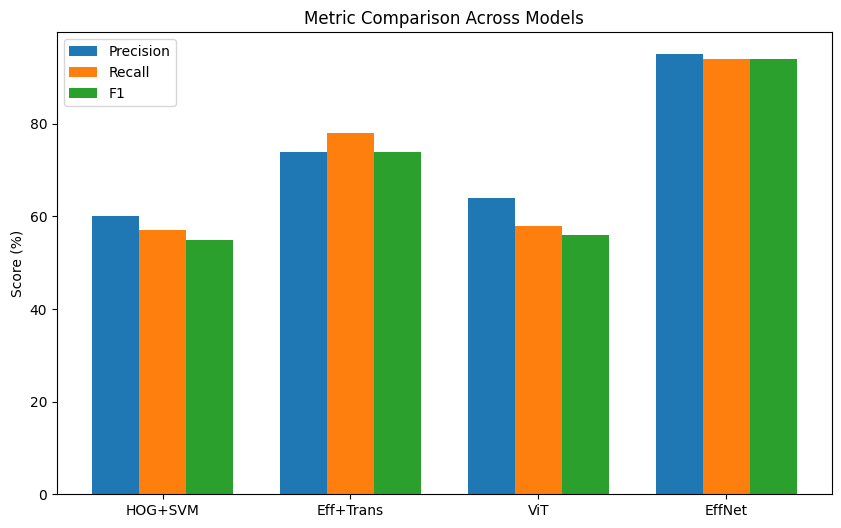

In [42]:
import numpy as np

models = [
    "HOG+SVM",
    "Eff+Trans",
    "ViT",
    "EffNet"
]

precision = [60,74,64,95]
recall    = [57,78,58,94]
f1        = [55,74,56,94]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x-width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x+width, f1, width, label="F1")

plt.xticks(x, models)

plt.ylabel("Score (%)")

plt.legend()

plt.title("Metric Comparison Across Models")

plt.savefig("metric_model_comparison.png", dpi=300)

plt.show()

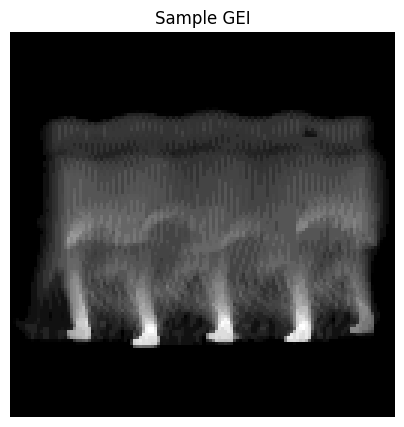

In [43]:
plt.figure(figsize=(5,5))

plt.imshow(X[0], cmap="gray")

plt.title("Sample GEI")

plt.axis("off")

plt.savefig("sample_gei.png", dpi=300)

plt.show()

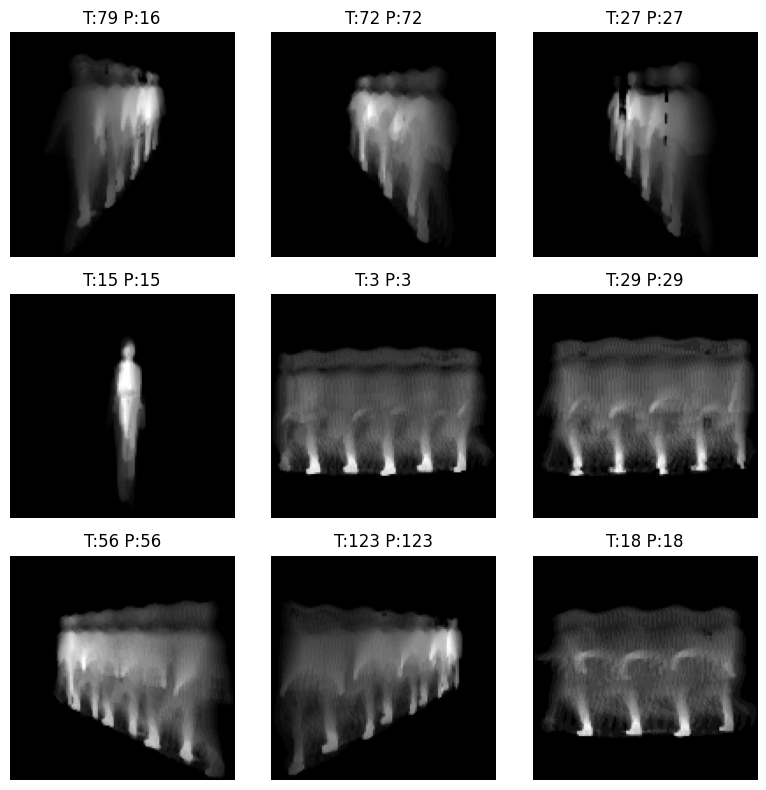

In [44]:
import random

indices = random.sample(
    range(len(X_test)),
    9
)

fig, axes = plt.subplots(3,3, figsize=(8,8))

for ax, idx in zip(axes.ravel(), indices):

    ax.imshow(X_test[idx], cmap='gray')

    ax.set_title(
        f"T:{y_test[idx]} P:{predictions[idx]}"
    )

    ax.axis('off')

plt.tight_layout()

plt.savefig("prediction_examples.png", dpi=300)

plt.show()

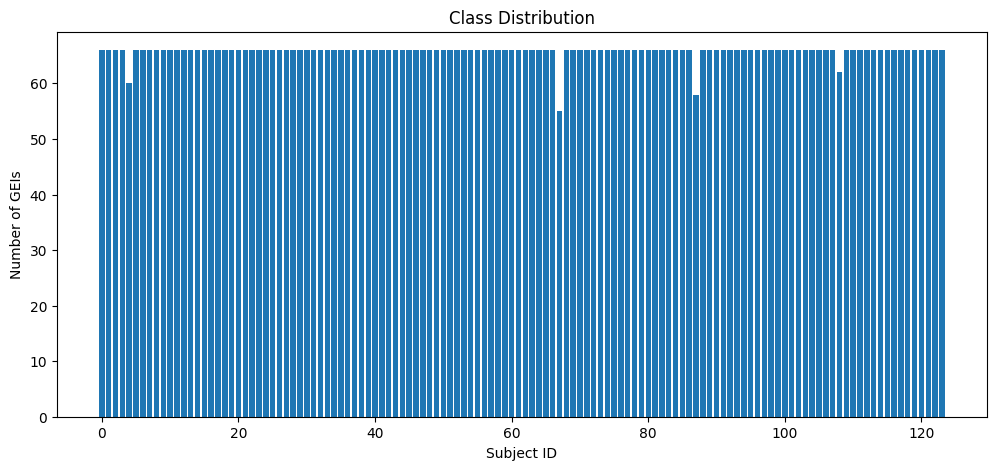

In [45]:
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(12,5))

plt.bar(unique, counts)

plt.xlabel("Subject ID")
plt.ylabel("Number of GEIs")

plt.title("Class Distribution")

plt.savefig("class_distribution.png", dpi=300)

plt.show()

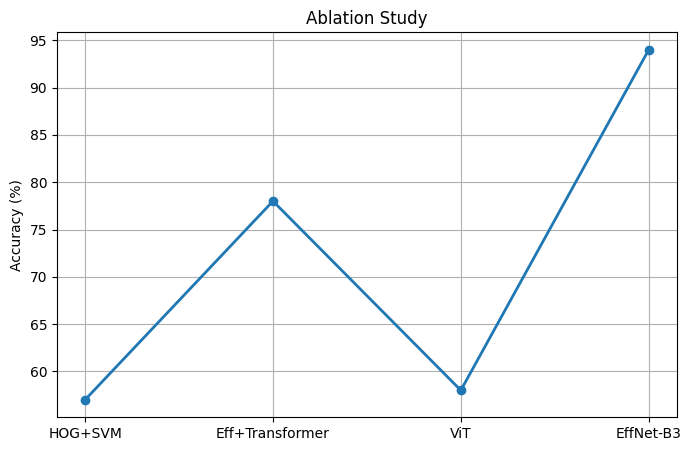

In [46]:
models = [
    "HOG+SVM",
    "Eff+Transformer",
    "ViT",
    "EffNet-B3"
]

acc = [
    57,
    78,
    58,
    94
]

plt.figure(figsize=(8,5))

plt.plot(
    models,
    acc,
    marker='o',
    linewidth=2
)

plt.ylabel("Accuracy (%)")

plt.title("Ablation Study")

plt.grid(True)

plt.savefig("ablation_study.png", dpi=300)

plt.show()

In [47]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

print("Memory cleared")

Memory cleared


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import timm
import os

In [ ]:
class GaitDatasetViT(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]

        image = np.expand_dims(image, axis=0)
        image = np.repeat(image, 3, axis=0)

        image = torch.tensor(image, dtype=torch.float32)

        image = F.interpolate(
            image.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        label = torch.tensor(self.y[idx], dtype=torch.long)

        return image, label

In [20]:
DATASET_ROOT = "/root/.cache/kagglehub/datasets/yeeandres/casiagdb/versions/1/GaitDatasetB-silh"

In [21]:
SAVE_ROOT = "/content/drive/MyDrive/CASIA-B/GEI_Multiview_NM"

In [22]:
np.save("X_multiview_nm.npy", X)
np.save("y_multiview_nm.npy", y)

NameError: name 'X' is not defined

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import timm
import os

In [2]:
class GaitDatasetViT(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]

        image = np.expand_dims(image, axis=0)
        image = np.repeat(image, 3, axis=0)

        image = torch.tensor(image, dtype=torch.float32)

        image = F.interpolate(
            image.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        label = torch.tensor(self.y[idx], dtype=torch.long)

        return image, label

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

NameError: name 'X' is not defined

In [3]:
train_dataset_vit = GaitDatasetViT(X_train, y_train)
test_dataset_vit = GaitDatasetViT(X_test, y_test)

train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

NameError: name 'X_train' is not defined

In [ ]:
import os

print("Total files:", len(os.listdir(GEI_ROOT)))

sample = os.path.join(
    GEI_ROOT,
    os.listdir(GEI_ROOT)[0]
)

print(sample)

In [ ]:
DATASET_ROOT = "/kaggle/input/datasets/yeeandres/casiagdb/GaitDatasetB-silh"

In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/yeeandres/casiagdb/GaitDatasetB-silh"

subjects = sorted([
    s for s in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, s))
])

print("Subjects:", len(subjects))
print(subjects[:10])

In [ ]:
USE_CONDITIONS = ["nm"]
USE_VIEWS = ["090"]

In [ ]:
print(X.shape)
print(len(np.unique(y)))

In [ ]:
print(DATASET_ROOT)

In [ ]:
# ==========================================================
# 1. Imports
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# ==========================================================
# 2. Dataset Root
# ==========================================================

DATASET_ROOT = "/kaggle/input/datasets/yeeandres/casiagdb/GaitDatasetB-silh"

subjects = sorted([
    s for s in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, s))
])

print("Subjects:", len(subjects))
print(subjects[:10])

In [ ]:
# ==========================================================
# 3. GEI Generation Function
# ==========================================================

def generate_gei(sequence_folder, image_size=(128, 128)):
    images = []

    for file in sorted(os.listdir(sequence_folder)):
        if not file.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        img_path = os.path.join(sequence_folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, image_size)
        img = img / 255.0
        images.append(img)

    if len(images) == 0:
        return None

    return np.mean(images, axis=0)

In [ ]:
# ==========================================================
# 4. Load GEIs from Full CASIA-B
# Structure:
# subject/subject/condition/view/images
# Example:
# 057/057/nm-01/090/*.png
# ==========================================================

X = []
y = []

USE_CONDITIONS = ["nm"]     # first run: normal walking only
USE_VIEWS = ["090"]         # first run: same-view 90 degree
MAX_SUBJECTS = 124

subjects = subjects[:MAX_SUBJECTS]

subject_map = {subject: idx for idx, subject in enumerate(subjects)}

for subject in tqdm(subjects, desc="Generating GEIs"):
    subject_path = os.path.join(DATASET_ROOT, subject, subject)

    if not os.path.isdir(subject_path):
        subject_path = os.path.join(DATASET_ROOT, subject)

    label = subject_map[subject]

    for condition in os.listdir(subject_path):
        condition_path = os.path.join(subject_path, condition)

        if not os.path.isdir(condition_path):
            continue

        if not any(condition.startswith(c) for c in USE_CONDITIONS):
            continue

        for view in os.listdir(condition_path):
            view_path = os.path.join(condition_path, view)

            if not os.path.isdir(view_path):
                continue

            if view not in USE_VIEWS:
                continue

            gei = generate_gei(view_path)

            if gei is not None:
                X.append(gei)
                y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", len(np.unique(y)))

In [ ]:
# ==========================================================
# 5. Visualize Sample GEI
# ==========================================================

plt.imshow(X[0], cmap="gray")
plt.title("Sample GEI")
plt.axis("off")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
class GaitDatasetEfficientNet(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        image = np.expand_dims(image, axis=0)
        image = np.repeat(image, 3, axis=0)
        image = torch.tensor(image, dtype=torch.float32)

        image = F.interpolate(
            image.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        label = torch.tensor(self.y[idx], dtype=torch.long)
        return image, label

In [ ]:
train_dataset = GaitDatasetEfficientNet(X_train, y_train)
test_dataset = GaitDatasetEfficientNet(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [ ]:
class EfficientNetOnlyModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetOnlyModel, self).__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )

        self.classifier = nn.Linear(1536, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_classes = len(np.unique(y))

eff_model = EfficientNetOnlyModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(eff_model.parameters(), lr=0.0001)

In [ ]:
best_acc = 0.0
CHECKPOINT_PATH = "/kaggle/working/efficientnet_b3_best.pth"

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):
    eff_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = eff_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss:.4f} "
        f"Train Accuracy: {train_acc:.4f}"
    )

In [ ]:
eff_model.eval()

predictions = []
ground_truth = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = eff_model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        ground_truth.extend(labels.numpy())

accuracy = accuracy_score(ground_truth, predictions)

print("EfficientNet-B3 Accuracy:", accuracy)
print(classification_report(ground_truth, predictions, zero_division=0))
print(confusion_matrix(ground_truth, predictions))

In [ ]:
"/kaggle/working/efficientnet_b3_nm_090_95acc.pth"

In [ ]:
USE_CONDITIONS = ["nm"]
USE_VIEWS = ["000","018","036","054","072","090","108","126","144","162","180"]

In [ ]:
# ==========================================================
# Multi-view NM GEI Loading with Checkpoint Resume
# ==========================================================

import os
import pickle
import numpy as np
from tqdm import tqdm

CHECKPOINT_FILE = "/kaggle/working/gei_generation_checkpoint.pkl"

USE_CONDITIONS = ["nm"]

USE_VIEWS = [
    "000", "018", "036", "054", "072",
    "090",
    "108", "126", "144", "162", "180"
]

MAX_SUBJECTS = 124

subjects = sorted([
    s for s in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, s))
])[:MAX_SUBJECTS]

subject_map = {subject: idx for idx, subject in enumerate(subjects)}

# Resume if checkpoint exists
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "rb") as f:
        data = pickle.load(f)

    X = data["X"]
    y = data["y"]
    processed_subjects = set(data["processed_subjects"])

    print("Resuming...")
    print("Already processed:", len(processed_subjects))

else:
    X = []
    y = []
    processed_subjects = set()

for subject in tqdm(subjects, desc="Generating Multi-view GEIs"):

    # Skip already completed subjects
    if subject in processed_subjects:
        continue

    subject_path = os.path.join(DATASET_ROOT, subject, subject)

    if not os.path.isdir(subject_path):
        subject_path = os.path.join(DATASET_ROOT, subject)

    label = subject_map[subject]

    for condition in os.listdir(subject_path):
        condition_path = os.path.join(subject_path, condition)

        if not os.path.isdir(condition_path):
            continue

        if not any(condition.startswith(c) for c in USE_CONDITIONS):
            continue

        for view in os.listdir(condition_path):
            view_path = os.path.join(condition_path, view)

            if not os.path.isdir(view_path):
                continue

            if view not in USE_VIEWS:
                continue

            gei = generate_gei(view_path)

            if gei is not None:
                X.append(gei)
                y.append(label)

    # Save checkpoint after each subject
    processed_subjects.add(subject)

    with open(CHECKPOINT_FILE, "wb") as f:
        pickle.dump(
            {
                "X": X,
                "y": y,
                "processed_subjects": list(processed_subjects)
            },
            f
        )

    print(f"Checkpoint saved after subject {subject}")

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", len(np.unique(y)))

# Save final numpy arrays
np.save("/kaggle/working/X_multiview_nm.npy", X)
np.save("/kaggle/working/y_multiview_nm.npy", y)

print("Final GEI arrays saved.")

In [ ]:
X.shape
y.shape

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", len(np.unique(y)))

In [ ]:
import numpy as np

np.save("/kaggle/working/X_multiview_nm.npy", X)
np.save("/kaggle/working/y_multiview_nm.npy", y)

print("Multi-view GEI dataset saved.")

In [ ]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

In [ ]:
num_classes = len(np.unique(y))

eff_model = EfficientNetOnlyModel(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(eff_model.parameters(), lr=0.0001)